In [ ]:
# Install dependencies (run once)
!pip install sentencepiece bert_score nltk -q

import os, sys, math, random, time
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm
import nltk
nltk.download('punkt', quiet=True)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IN_COLAB = 'google.colab' in sys.modules
BASE     = "/content" if IN_COLAB else "./nmt_workspace"
DATA_DIR = BASE + "/data"     
TOK_DIR  = BASE + "/tokenizers"
CKPT_DIR = BASE + "/checkpoints"
for d in [DATA_DIR, TOK_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

VOCAB_SIZE   = 4000     
EMBED_DIM    = 256      
HIDDEN_DIM   = 256      
NUM_LAYERS   = 2        
DROPOUT      = 0.3
BATCH_SIZE   = 64
MAX_LEN      = 128      
N_EPOCHS     = 40
LR           = 3e-4
WARMUP       = 5        
CLIP         = 1.0      
SMOOTH       = 0.1      
TF_START     = 1.0      
TF_END       = 0.3      


BEAM         = 4
LEN_PEN      = 0.7      
NO_REPEAT_N  = 3        
REP_PEN      = 1.5      
MIN_LEN      = 3        

In [6]:
train_sa = pd.read_csv(DATA_DIR + "/train_sa_10000.csv")
train_en = pd.read_csv(DATA_DIR + "/train_en_10000.csv")

print("Train pairs:", len(train_sa))
print("IDs aligned:", (train_sa['Source_id'].values == train_en['Source_id'].values).all())

sa_words = set()
for s in train_sa['Sentence_sa'].astype(str):
    sa_words.update(s.split())
en_words = set()
for s in train_en['Sentence_en'].astype(str):
    en_words.update(s.lower().split())

print("Unique Sanskrit words:", len(sa_words))
print("Unique English words:", len(en_words))
print("Sanskrit vocab / sentences =", round(len(sa_words) / len(train_sa), 2))

print()
print("Example pair:")
print("SA:", train_sa['Sentence_sa'].iloc[0])
print("EN:", train_en['Sentence_en'].iloc[0])

Train pairs: 10000
IDs aligned: True
Unique Sanskrit words: 33274
Unique English words: 17628
Sanskrit vocab / sentences = 3.33

Example pair:
SA: "Ctrl, S नुत्वा रक्षन्तु।"
EN: Save it with Ctrl, S.


In [ ]:
def dump_column(csv_path, col, out_path):
    df = pd.read_csv(csv_path)
    with open(out_path, "w", encoding="utf-8") as f:
        for s in df[col].astype(str):
            f.write(s.strip() + "\n")

dump_column(DATA_DIR + "/train_sa_10000.csv", "Sentence_sa", TOK_DIR + "/train_sa.txt")
dump_column(DATA_DIR + "/train_en_10000.csv", "Sentence_en", TOK_DIR + "/train_en.txt")

for lang, coverage in [("sa", 0.9995), ("en", 1.0)]:
    spm.SentencePieceTrainer.train(
        input=TOK_DIR + "/train_" + lang + ".txt",
        model_prefix=TOK_DIR + "/" + lang + "_bpe",
        vocab_size=VOCAB_SIZE,
        model_type="bpe",
        character_coverage=coverage, 
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        pad_piece="<pad>", unk_piece="<unk>", bos_piece="<bos>", eos_piece="<eos>")

sp_sa = spm.SentencePieceProcessor(model_file=TOK_DIR + "/sa_bpe.model")
sp_en = spm.SentencePieceProcessor(model_file=TOK_DIR + "/en_bpe.model")

sample = train_sa['Sentence_sa'].iloc[0]
print("Sample:", sample)
print("Pieces:", sp_sa.encode(sample, out_type=str))
print("SA vocab:", sp_sa.vocab_size(), "| EN vocab:", sp_en.vocab_size())

Sample: "Ctrl, S नुत्वा रक्षन्तु।"
Pieces: ['▁"', 'C', 'trl', ',', '▁S', '▁नुत्वा', '▁रक्ष', 'न्तु', '।"']
SA vocab: 4000 | EN vocab: 4000


In [8]:
class NMTDataset(Dataset):
    def __init__(self, sa_csv, en_csv):
        sa_df = pd.read_csv(sa_csv)
        en_df = pd.read_csv(en_csv)
        assert (sa_df['Source_id'].values == en_df['Source_id'].values).all()
        self.sa = sa_df['Sentence_sa'].astype(str).tolist()
        self.en = en_df['Sentence_en'].astype(str).tolist()
        self.ids = sa_df['Source_id'].tolist()

    def __len__(self):
        return len(self.sa)

    def __getitem__(self, i):
        src = sp_sa.encode(self.sa[i], out_type=int)[:MAX_LEN - 1] + [EOS_ID]
        tgt = [BOS_ID] + sp_en.encode(self.en[i], out_type=int)[:MAX_LEN - 2] + [EOS_ID]
        return {"src": torch.tensor(src), "tgt": torch.tensor(tgt), "id": self.ids[i]}

def collate(batch):
    src = nn.utils.rnn.pad_sequence([b["src"] for b in batch], batch_first=True, padding_value=PAD_ID)
    tgt = nn.utils.rnn.pad_sequence([b["tgt"] for b in batch], batch_first=True, padding_value=PAD_ID)
    return {"src": src, "tgt": tgt, "src_mask": src != PAD_ID,
            "ids": [b["id"] for b in batch]}

train_loader = DataLoader(NMTDataset(DATA_DIR + "/train_sa_10000.csv", DATA_DIR + "/train_en_10000.csv"),
                          BATCH_SIZE, shuffle=True, collate_fn=collate)
dev_loader   = DataLoader(NMTDataset(DATA_DIR + "/dev_sa_1000.csv", DATA_DIR + "/dev_en_1000.csv"),
                          BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(NMTDataset(DATA_DIR + "/test_sa_1000.csv", DATA_DIR + "/test_en_1000.csv"),
                          BATCH_SIZE, shuffle=False, collate_fn=collate)

b = next(iter(train_loader))
print("src batch:", b["src"].shape, "| tgt batch:", b["tgt"].shape)

src batch: torch.Size([64, 66]) | tgt batch: torch.Size([64, 52])


In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_ID)
        self.gru = nn.GRU(EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, batch_first=True,
                          bidirectional=True, dropout=DROPOUT)
        self.drop = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM)

    def forward(self, src, src_mask):
        x = self.drop(self.emb(src))
        lens = src_mask.sum(1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lens, batch_first=True,
                                                   enforce_sorted=False)
        out, hid = self.gru(packed)
        
        enc_out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True,
                                                      total_length=src.size(1))
        dec_init = torch.tanh(self.fc(torch.cat([hid[-2], hid[-1]], dim=1)))
        return enc_out, dec_init


class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM, bias=False)

    def forward(self, query, enc_out, src_mask):
        keys = self.proj(enc_out)                                 
        scores = torch.bmm(keys, query.unsqueeze(2)).squeeze(2)   
        scores = scores.masked_fill(~src_mask, float("-inf"))     
        w = F.softmax(scores, dim=1)
        context = torch.bmm(w.unsqueeze(1), enc_out).squeeze(1)   
        return context, w


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_ID)
        self.att = Attention()
        self.drop = nn.Dropout(DROPOUT)
        self.gru = nn.GRU(EMBED_DIM + HIDDEN_DIM * 2, HIDDEN_DIM, NUM_LAYERS,
                          batch_first=True, dropout=DROPOUT)
        self.out = nn.Linear(HIDDEN_DIM + HIDDEN_DIM * 2, VOCAB_SIZE)

    def step(self, tok, hidden, enc_out, src_mask):
        e = self.drop(self.emb(tok)).unsqueeze(1)                 
        ctx, w = self.att(hidden[-1], enc_out, src_mask)
        o, hidden = self.gru(torch.cat([e, ctx.unsqueeze(1)], dim=2), hidden)
        logits = self.out(torch.cat([o.squeeze(1), ctx], dim=1))
        return logits, hidden, w

    def forward(self, tgt, hidden, enc_out, src_mask, tf_ratio):
        B, T = tgt.size()
        logits_all = torch.zeros(B, T - 1, VOCAB_SIZE, device=tgt.device)
        inp = tgt[:, 0]                                            
        for t in range(T - 1):
            logits, hidden, _ = self.step(inp, hidden, enc_out, src_mask)
            logits_all[:, t] = logits
            if random.random() < tf_ratio:
                inp = tgt[:, t + 1]
            else:
                inp = logits.argmax(1)
        return logits_all


class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, src, tgt, src_mask, tf_ratio):
        enc_out, dec_init = self.encoder(src, src_mask)
        hidden = dec_init.unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        return self.decoder(tgt, hidden, enc_out, src_mask, tf_ratio)

    @torch.no_grad()
    def beam_search(self, src, src_mask):
        self.eval()
        enc_out, dec_init = self.encoder(src, src_mask)
        hidden = dec_init.unsqueeze(0).repeat(NUM_LAYERS, 1, 1)
        beams = [(0.0, [BOS_ID], hidden, set())]
        finished = []

        for step in range(MAX_LEN):
            candidates = []
            for score, seq, hid, seen in beams:
                if seq[-1] == EOS_ID:
                    finished.append((score, seq))
                    continue
                tok = torch.tensor([seq[-1]], device=src.device)
                logits, new_hid, _ = self.decoder.step(tok, hid, enc_out, src_mask)
                logp = F.log_softmax(logits, dim=-1).squeeze(0)

                for t in set(seq):
                    if logp[t] < 0:
                        logp[t] = logp[t] * REP_PEN

                if len(seq) >= NO_REPEAT_N - 1:
                    prefix = tuple(seq[-(NO_REPEAT_N - 1):])
                    for ng in seen:
                        if ng[:-1] == prefix:
                            logp[ng[-1]] = float("-inf")

                logp[seq[-1]] = float("-inf")   
                logp[UNK_ID] = float("-inf")    
                if step < MIN_LEN:
                    logp[EOS_ID] = float("-inf")

                top_p, top_i = logp.topk(BEAM)
                for lp_val, t in zip(top_p.tolist(), top_i.tolist()):
                    new_seq = seq + [t]
                    new_seen = seen
                    if len(new_seq) >= NO_REPEAT_N:
                        new_seen = seen | {tuple(new_seq[-NO_REPEAT_N:])}
                    candidates.append((score + lp_val, new_seq, new_hid, new_seen))

            if not candidates:
                break
            candidates.sort(key=lambda c: c[0] / len(c[1]) ** LEN_PEN, reverse=True)
            beams = candidates[:BEAM]
            if all(b[1][-1] == EOS_ID for b in beams):
                finished += [(b[0], b[1]) for b in beams]
                break

        if not finished:
            finished = [(b[0], b[1]) for b in beams]
        best = max(finished, key=lambda c: c[0] / len(c[1]) ** LEN_PEN)[1]
        return [t for t in best if t not in (BOS_ID, EOS_ID, PAD_ID)]


model = Seq2Seq().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", n_params)

Trainable parameters: 8541344


In [ ]:
def smooth_loss(logits, targets):
    with torch.no_grad():
        dist = torch.full_like(logits, SMOOTH / (VOCAB_SIZE - 2))
        dist.scatter_(1, targets.unsqueeze(1), 1.0 - SMOOTH)
        dist[targets == PAD_ID] = 0.0
    logp = torch.log_softmax(logits, dim=-1)
    loss = -(dist * logp).sum(-1)
    n = (targets != PAD_ID).sum()
    return loss.sum() / n.clamp(min=1)

def lr_at(epoch):
    if epoch < WARMUP:
        return LR * (epoch + 1) / WARMUP
    p = (epoch - WARMUP) / max(1, N_EPOCHS - WARMUP)
    return LR * 0.5 * (1 + math.cos(math.pi * p))

def tf_at(epoch):
    p = epoch / max(1, N_EPOCHS - 1)
    return TF_START - p * (TF_START - TF_END)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
best_dev = float("inf")
history = []

print(f"{'Ep':>3} {'TrainLoss':>10} {'DevLoss':>9} {'TF':>5} {'Time':>6}")
for epoch in range(N_EPOCHS):
    for g in optimizer.param_groups:
        g['lr'] = lr_at(epoch)
    tf = tf_at(epoch)
    t0 = time.time()

    model.train()
    total, count = 0.0, 0
    for b in train_loader:
        src, tgt, mask = b['src'].to(device), b['tgt'].to(device), b['src_mask'].to(device)
        optimizer.zero_grad()
        logits = model(src, tgt, mask, tf)
        targets = tgt[:, 1:].reshape(-1)
        loss = smooth_loss(logits.reshape(-1, VOCAB_SIZE), targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        n = (targets != PAD_ID).sum().item()
        total += loss.item() * n
        count += n
    train_loss = total / count

    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for b in dev_loader:
            src, tgt, mask = b['src'].to(device), b['tgt'].to(device), b['src_mask'].to(device)
            logits = model(src, tgt, mask, 0.0)
            targets = tgt[:, 1:].reshape(-1)
            loss = smooth_loss(logits.reshape(-1, VOCAB_SIZE), targets)
            n = (targets != PAD_ID).sum().item()
            total += loss.item() * n
            count += n
    dev_loss = total / count

    saved = ""
    if dev_loss < best_dev:
        best_dev = dev_loss
        torch.save({"model": model.state_dict(), "epoch": epoch, "dev_loss": dev_loss},
                   CKPT_DIR + "/best.pt")
        saved = " (saved)"
    history.append((epoch + 1, train_loss, dev_loss))
    print(f"{epoch+1:>3} {train_loss:>10.4f} {dev_loss:>9.4f} {tf:>5.2f} {time.time()-t0:>5.0f}s{saved}")

print("Best dev loss:", round(best_dev, 4))

 Ep  TrainLoss   DevLoss    TF   Time
  1     7.3048    6.7807  1.00    41s (saved)
  2     6.6161    6.8502  0.98    37s
  3     6.4214    6.7835  0.96    96s
  4     6.2246    6.8466  0.95    97s
  5     6.0251    6.7761  0.93    97s (saved)
  6     5.8661    6.8462  0.91   102s
  7     5.7457    6.7257  0.89    91s (saved)
  8     5.6472    6.7810  0.87    99s
  9     5.5497    6.7577  0.86    58s
 10     5.4762    6.6859  0.84    69s (saved)
 11     5.4053    6.6678  0.82    75s (saved)
 12     5.3515    6.6732  0.80    77s
 13     5.2873    6.6239  0.78    44s (saved)
 14     5.2486    6.5605  0.77    37s (saved)
 15     5.2030    6.5500  0.75    37s (saved)
 16     5.1727    6.4980  0.73    38s (saved)
 17     5.1315    6.4877  0.71    37s (saved)
 18     5.0901    6.4645  0.69    38s (saved)
 19     5.0564    6.4498  0.68    41s (saved)
 20     5.0309    6.4407  0.66    37s (saved)
 21     5.0253    6.3916  0.64    38s (saved)
 22     5.0021    6.3642  0.62    40s (saved)
 23   

In [11]:
ckpt = torch.load(CKPT_DIR + "/best.pt", map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()
print("Loaded epoch", ckpt["epoch"] + 1, "dev_loss", round(ckpt["dev_loss"], 4))

def translate(sentence):
    ids = sp_sa.encode(str(sentence), out_type=int)[:MAX_LEN - 1] + [EOS_ID]
    src = torch.tensor([ids], device=device)
    mask = src != PAD_ID
    out = model.beam_search(src, mask)
    return sp_en.decode(out)

dev_sa = pd.read_csv(DATA_DIR + "/dev_sa_1000.csv")
dev_en = pd.read_csv(DATA_DIR + "/dev_en_1000.csv")
for i in range(5):
    print("SA :", dev_sa['Sentence_sa'].iloc[i])
    print("REF:", dev_en['Sentence_en'].iloc[i])
    print("HYP:", translate(dev_sa['Sentence_sa'].iloc[i]))
    print()

Loaded epoch 39 dev_loss 6.2238
SA : ते वीराः ।
REF: Those are brave men.
HYP: Those are twos.

SA : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
REF: Infinite loop  can cause the system to become unresponsive.
HYP: This brings us to the a news.

SA : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
REF: "And they spit upon him, and took the reed, and smote him on the head."
HYP: "And they took him, saying, The Lord of God,

SA : एते तिथी ।
REF: These two are dates.
HYP: These are teachers.

SA : "बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान्।"
REF: "And when there had been much disputing, Peter rose up, and said unto them, Men and brethren, ye know how that a good while ago God made choice among us, that the Gentiles by my mouth should hear the word of the gospel, and believe."
HYP: "And he said unto them, If I say unto him, Why, thou hast

In [12]:
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bert_score

def evaluate(loader, en_csv, name):
    en_df = pd.read_csv(en_csv)
    refs = [[s.lower().split()] for s in en_df['Sentence_en'].astype(str)]
    hyps = []
    for b in loader:
        src, mask = b['src'].to(device), b['src_mask'].to(device)
        for i in range(src.size(0)):
            out = model.beam_search(src[i:i+1], mask[i:i+1])
            hyps.append(sp_en.decode(out))
        if len(hyps) % 200 < BATCH_SIZE:
            print(" ", name, len(hyps), "done")
    bleu = corpus_bleu(refs, [h.lower().split() for h in hyps])
    _, _, F1 = bert_score(hyps, [r[0] for r in refs], lang="en",
                          rescale_with_baseline=True, verbose=False)
    print(f"{name} BLEU: {bleu*100:.2f} | BERTScore F1: {F1.mean().item():.4f}")
    return hyps, bleu, F1.mean().item()

test_hyps, test_bleu, test_bert = evaluate(test_loader, DATA_DIR + "/test_en_1000.csv", "Test")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
t0 = time.time()
test_sa = pd.read_csv(DATA_DIR + "/test_sa_1000.csv")
translate(test_sa['Sentence_sa'].iloc[0])
print("Parameters:", n_params, "| Inference time/sentence:", round(time.time() - t0, 3), "s")

  Test 256 done
  Test 448 done
  Test 640 done
  Test 832 done
  Test 1000 done


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test BLEU: 4.94 | BERTScore F1: 0.1611
Parameters: 8541344 | Inference time/sentence: 0.956 s


In [13]:
submission = pd.DataFrame({"Source_id": test_sa['Source_id'].tolist(),
                           "Sentence_en": test_hyps})
submission.to_csv(BASE + "/submission.csv", index=False)
print("Saved", BASE + "/submission.csv")
submission.head(10)

Saved ./nmt_workspace/submission.csv


,Source_id,Sentence_en
0,1,It is also to identify the project.
1,2,"""And if I say unto you, The Lord of God, and i..."
2,3,"But, I will click on Save button and then clic..."
3,4,"In this case, we will be used: for a file whic..."
4,5,"""For if we have to be, in the world, and of th..."
5,6,"In this tutorial, we learnt how to create a co..."
6,7,Child has love in you all.
7,8,It isves in the breathing and
8,9,"""And when he was no man, and to the, of God: f..."
9,10,"""It is a tree of the,s. It is also used to imp..."


In [14]:
test_en = pd.read_csv(DATA_DIR + "/test_en_1000.csv")
for i in range(10):
    print("Example", i + 1)
    print("  SA :", test_sa['Sentence_sa'].iloc[i])
    print("  REF:", test_en['Sentence_en'].iloc[i])
    print("  HYP:", test_hyps[i])
    print()

Example 1
  SA : एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
  REF: Eclipse also helps the programmer to find out errors.
  HYP: It is also to identify the project.

Example 2
  SA : विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते।
  REF: "We having the same spirit of faith, according as it is written, I believed, and therefore have I spoken; we also believe, and therefore speak;"
  HYP: "And if I say unto you, The Lord of God, and in the Father, that ye may be by me, but I will not be known."

Example 3
  SA : तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
  REF: Then it will automatically begin searching for drivers. I will click on Cancel.
  HYP: But, I will click on Save button and then click on it.

Example 4
  SA : सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्येकस्मै इण्डेक्स्-वेल्यू-इत्यस्मै सेट् क्रियते । 1,1 पश्चात् 1,2  एवम्…
  REF: T

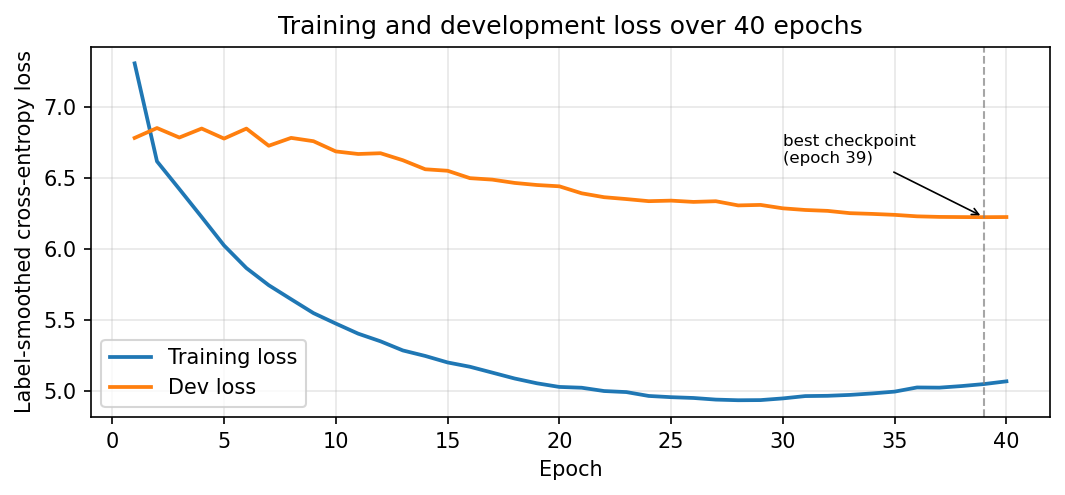

In [7]:
import matplotlib.pyplot as plt
train_curve = [7.3048,6.6161,6.4214,6.2246,6.0251,5.8661,5.7457,5.6472,5.5497,5.4762,
               5.4053,5.3515,5.2873,5.2486,5.2030,5.1727,5.1315,5.0901,5.0564,5.0309,
               5.0253,5.0021,4.9947,4.9675,4.9589,4.9533,4.9419,4.9374,4.9384,4.9503,
               4.9666,4.9685,4.9749,4.9852,4.9980,5.0272,5.0259,5.0371,5.0511,5.0703]
dev_curve   = [6.7807,6.8502,6.7835,6.8466,6.7761,6.8462,6.7257,6.7810,6.7577,6.6859,
               6.6678,6.6732,6.6239,6.5605,6.5500,6.4980,6.4877,6.4645,6.4498,6.4407,
               6.3916,6.3642,6.3510,6.3363,6.3401,6.3311,6.3359,6.3065,6.3100,6.2860,
               6.2744,6.2681,6.2520,6.2468,6.2401,6.2297,6.2257,6.2245,6.2238,6.2247]
history = list(zip(range(1, 41), train_curve, dev_curve))
epochs_x    = [h[0] for h in history]
train_curve = [h[1] for h in history]
dev_curve   = [h[2] for h in history]

best_ep = epochs_x[dev_curve.index(min(dev_curve))]

fig, ax = plt.subplots(figsize=(7.2, 3.4), dpi=150)
ax.plot(epochs_x, train_curve, label="Training loss", linewidth=1.8)
ax.plot(epochs_x, dev_curve,   label="Dev loss",      linewidth=1.8)
ax.axvline(best_ep, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate(f"best checkpoint\n(epoch {best_ep})",
            xy=(best_ep, min(dev_curve)),
            xytext=(best_ep - 9, min(dev_curve) + 0.38),
            fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("Epoch")
ax.set_ylabel("Label-smoothed cross-entropy loss")
ax.set_title("Training and development loss over " + str(len(epochs_x)) + " epochs")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/training_curve.png")  
plt.show()